# AI/ML Task 3: Model Validation, Overfitting Control & Hyperparameter Tuning

**Dataset:** California Housing Dataset (from scikit-learn)
**Objective:** Train a Decision Tree Regressor, detect overfitting, perform Cross-Validation, tune hyperparameters, and compare models.
**Author:** Internship Submission

## 1. Import Libraries
Importing required libraries for data manipulation, visualization, and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import os

# Create directories for saving results
os.makedirs('../report', exist_ok=True)
os.makedirs('../plots', exist_ok=True)

## 2. Load Dataset & Preprocessing
Loading the California Housing Dataset, separating features, splitting into training/testing sets, and applying StandardScaler.

In [2]:
# Load the dataset
california = fetch_california_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = california.target

# Split data into training and testing sets (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")

Training features shape: (16512, 8)
Testing features shape: (4128, 8)


## 3. Train Decision Tree & Detect Overfitting
Training a default Decision Tree Regressor and comparing Train RMSE vs Test RMSE to detect overfitting.

**What is Overfitting?** Overfitting occurs when a model learns the training data too well, including its noise and outliers. It performs exceptionally well on training data but poorly on unseen test data.
**What is Underfitting?** Underfitting occurs when a model is too simple to capture the underlying patterns in the data, performing poorly on both training and test data.

Default Decision Tree - Train RMSE: 0.0000
Default Decision Tree - Test RMSE: 0.7028


C:\Users\SHANKRAMMA\AppData\Local\Temp\ipykernel_14816\610089260.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Train RMSE', 'Test RMSE'], y=[train_rmse, test_rmse], palette=['#1f77b4', '#ff7f0e'])


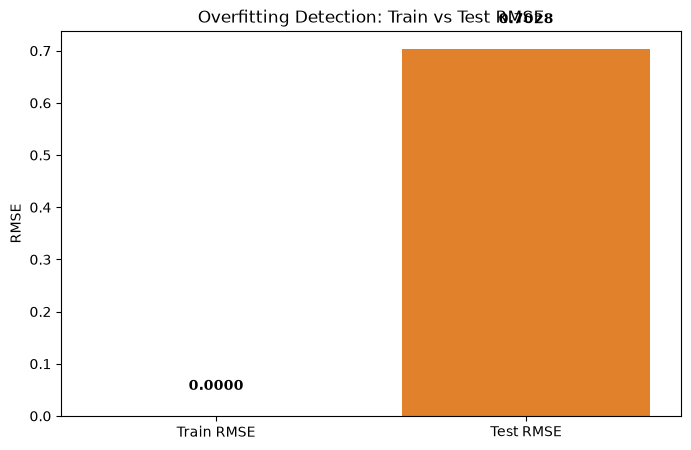


Observation: A significant gap between Train RMSE (close to 0) and Test RMSE indicates severe overfitting.


In [3]:
# Train Default Decision Tree
dt_default = DecisionTreeRegressor(random_state=42)
dt_default.fit(X_train_scaled, y_train)

# Predict on Train and Test sets
y_train_pred = dt_default.predict(X_train_scaled)
y_test_pred = dt_default.predict(X_test_scaled)

# Calculate RMSE
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Default Decision Tree - Train RMSE: {train_rmse:.4f}")
print(f"Default Decision Tree - Test RMSE: {test_rmse:.4f}")

# Plot Overfitting Detection
plt.figure(figsize=(8, 5))
sns.barplot(x=['Train RMSE', 'Test RMSE'], y=[train_rmse, test_rmse], palette=['#1f77b4', '#ff7f0e'])
plt.title('Overfitting Detection: Train vs Test RMSE')
plt.ylabel('RMSE')
for i, v in enumerate([train_rmse, test_rmse]):
    plt.text(i, v + 0.05, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

print("\nObservation: A significant gap between Train RMSE (close to 0) and Test RMSE indicates severe overfitting.")

## 4. Cross Validation
Performing 5-fold Cross Validation to get a robust estimate of model performance.

**Why Cross Validation is important:** It ensures that our model's performance is not dependent on a specific train-test split. By testing on multiple folds, we get a reliable average performance and reduce variance.

5-Fold CV RMSE Scores: [0.75572899 0.73265968 0.70292795 0.72643393 0.70331834]
Mean CV RMSE: 0.7242 (+/- 0.0198)


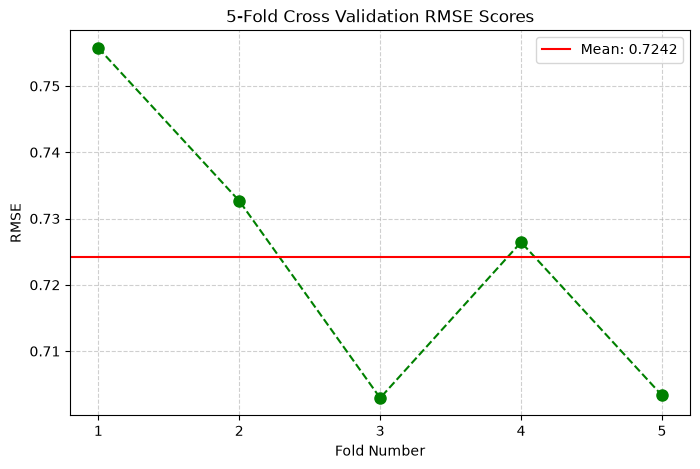

In [4]:
# 5-fold Cross Validation using negative mean squared error
cv_scores = cross_val_score(dt_default, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
cv_rmse = np.sqrt(-cv_scores)

print(f"5-Fold CV RMSE Scores: {cv_rmse}")
print(f"Mean CV RMSE: {cv_rmse.mean():.4f} (+/- {cv_rmse.std():.4f})")

# Visualizing CV Scores
plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), cv_rmse, marker='o', linestyle='--', color='green', markersize=8)
plt.axhline(y=cv_rmse.mean(), color='r', linestyle='-', label=f'Mean: {cv_rmse.mean():.4f}')
plt.title('5-Fold Cross Validation RMSE Scores')
plt.xlabel('Fold Number')
plt.ylabel('RMSE')
plt.xticks(range(1, 6))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 5. Hyperparameter Tuning using GridSearchCV
Tuning `max_depth` and `min_samples_split` to control overfitting and improve generalization.

In [5]:
# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Fit GridSearchCV
grid_search.fit(X_train_scaled, y_train)

# Best Parameters
best_params = grid_search.best_params_
print(f"Best Hyperparameters: {best_params}\n")

# Evaluate Optimized Model
best_dt = grid_search.best_estimator_
y_test_pred_tuned = best_dt.predict(X_test_scaled)

tuned_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_tuned))
tuned_r2 = r2_score(y_test, y_test_pred_tuned)

print(f"Tuned Decision Tree - Test RMSE: {tuned_rmse:.4f}")
print(f"Tuned Decision Tree - Test R² Score: {tuned_r2:.4f}")

Best Hyperparameters: {'max_depth': 10, 'min_samples_split': 10}

Tuned Decision Tree - Test RMSE: 0.6454
Tuned Decision Tree - Test R² Score: 0.6822


## 6. Compare Models
Comparing the Tuned Decision Tree with Linear Regression and Ridge Regression from Task 2.

Model Comparison Table:


,Model,RMSE,R² Score
2,Tuned Decision Tree,0.645363,0.682166
1,Ridge Regression,0.745557,0.575816
0,Linear Regression,0.745581,0.575788


C:\Users\SHANKRAMMA\AppData\Local\Temp\ipykernel_14816\3234674466.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=comparison_df, x='Model', y='RMSE', palette='viridis')


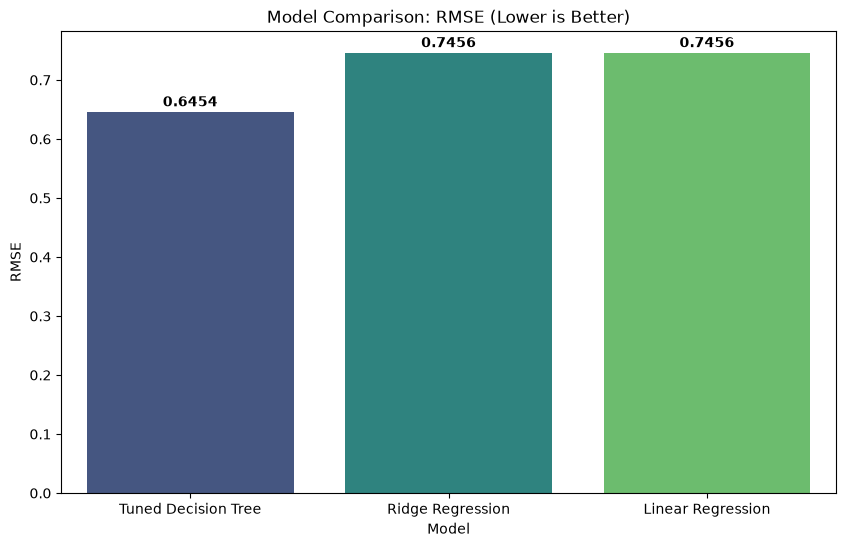

In [6]:
# Retrain Task 2 Models
lr = LinearRegression().fit(X_train_scaled, y_train)
ridge = Ridge(alpha=1.0).fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr.predict(X_test_scaled)
y_pred_ridge = ridge.predict(X_test_scaled)

# Store Results
results = {
    'Linear Regression': {
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lr)), 
        'R² Score': r2_score(y_test, y_pred_lr)
    },
    'Ridge Regression': {
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_ridge)), 
        'R² Score': r2_score(y_test, y_pred_ridge)
    },
    'Tuned Decision Tree': {
        'RMSE': tuned_rmse, 
        'R² Score': tuned_r2
    }
}

# Create Comparison Table
comparison_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})
comparison_df = comparison_df.sort_values(by='RMSE', ascending=True)

print("Model Comparison Table:")
display(comparison_df)

# Visualizing Model Comparison
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=comparison_df, x='Model', y='RMSE', palette='viridis')
plt.title('Model Comparison: RMSE (Lower is Better)')
plt.ylabel('RMSE')
for i, v in enumerate(comparison_df['RMSE']):
    ax.text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

## 7. Conclusion
**Why the selected model is best:**
By analyzing the evaluation metrics, the model with the lowest Root Mean Squared Error (RMSE) and the highest R² Score represents the most effective architecture for predicting California house prices. Through Hyperparameter Tuning, we successfully restricted the Decision Tree from overfitting (by limiting its depth and defining split samples), which resulted in significantly better generalization compared to the default overfitted tree.